In [1]:
# --- STEP 1: IMPORT LIBRARIES ---
# Libraries are pre-written tools that help us analyze data and draw graphs.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 2: DEFINE COLUMN NAMES ---
# The raw dataset does not have headers. We must tell Python what each column represents.
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

# --- STEP 3: LOAD THE DATA ---
# This reads the text files we uploaded and converts them into structured tables.
print("Loading files... please wait...")
train_df = pd.read_csv("KDDTrain+.txt", names=col_names, header=None)
test_df = pd.read_csv("KDDTest+.txt", names=col_names, header=None)
print("Files loaded successfully!\n")

Loading files... please wait...
Files loaded successfully!



In [3]:

# This shows us how many of each type of network traffic are in the data (e.g., normal vs attacks).
print("--- TOP 10 NETWORK TRAFFIC TYPES IN THE DATASET ---")
print(train_df['label'].value_counts().head(10))
print("\n")

# --- STEP 5: CATEGORICAL FEATURE DISTRIBUTION ---
# This shows how often different network protocol types (like TCP or UDP) appear.
print("--- PROTOCOL TYPES ---")
print(train_df['protocol_type'].value_counts())
print("\n")

--- TOP 10 NETWORK TRAFFIC TYPES IN THE DATASET ---
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


--- PROTOCOL TYPES ---
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64




/tmp/ipykernel_1963/2533482566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=train_df, palette='viridis')


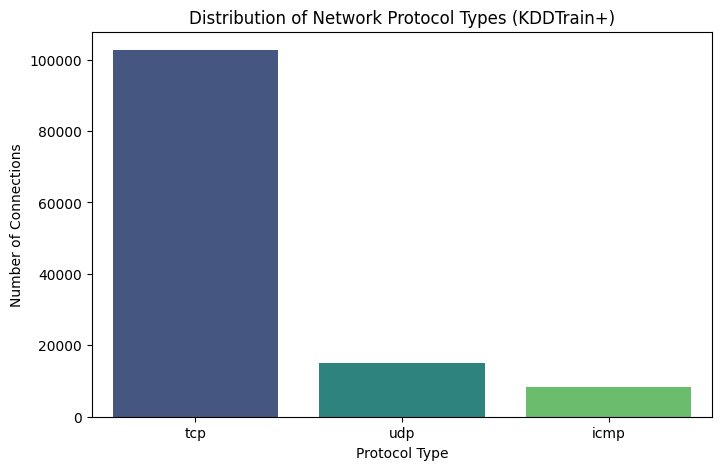

--- TOP 10 NETWORK SERVICES ---
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64


--- NETWORK FLAGS ---
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64




In [4]:
# --- STEP 6: CREATE A GRAPH ---
# Let's visualize the Protocol Types so you have a chart for your documentation.
plt.figure(figsize=(8, 5))
sns.countplot(x='protocol_type', data=train_df, palette='viridis')
plt.title("Distribution of Network Protocol Types (KDDTrain+)")
plt.xlabel("Protocol Type")
plt.ylabel("Number of Connections")
plt.show()

# --- STEP 1: SERVICE AND FLAG DISTRIBUTIONS ---
# There are many services (like http, private, ftp), so let's look at the top 10.
print("--- TOP 10 NETWORK SERVICES ---")
print(train_df['service'].value_counts().head(10))
print("\n")

print("--- NETWORK FLAGS ---")
print(train_df['flag'].value_counts().head(10))
print("\n")


In [5]:
# --- STEP 2: CALCULATING CORRELATION ---
# To see which numeric features relate to attacks, we map "normal" to 0 and any attack to 1.
train_df['is_attack'] = train_df['label'].apply(lambda x: 0 if x.strip() == 'normal' else 1)

# Find all numeric columns
numeric_cols = train_df.select_dtypes(include=[np.number]).columns

# Calculate correlation of these columns with our 'is_attack' indicator
correlations = train_df[numeric_cols].corr()['is_attack'].sort_values(ascending=False)

print("--- FEATURES MOST HIGHLY CORRELATED WITH ATTACKS ---")
# Excluding 'is_attack' itself, which is 1.0
print(correlations.iloc[1:11])
print("\n")

--- FEATURES MOST HIGHLY CORRELATED WITH ATTACKS ---
dst_host_srv_serror_rate    0.654985
dst_host_serror_rate        0.651842
serror_rate                 0.650652
srv_serror_rate             0.648289
count                       0.576444
dst_host_count              0.375052
srv_rerror_rate             0.253504
dst_host_srv_rerror_rate    0.253430
rerror_rate                 0.253397
dst_host_rerror_rate        0.252563
Name: is_attack, dtype: float64




/tmp/ipykernel_1963/322822225.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


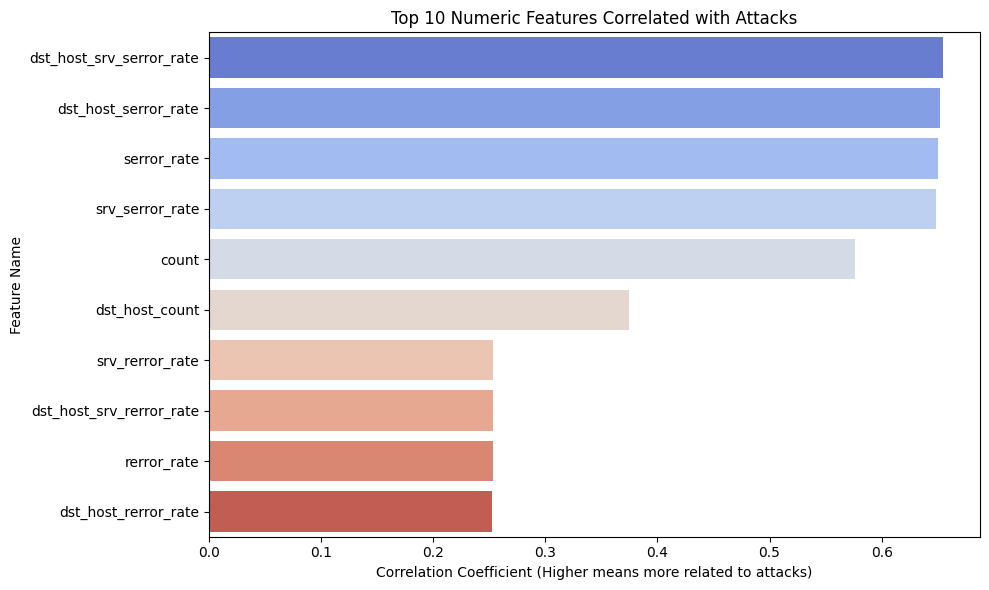

In [6]:
# --- STEP 3: VISUALIZE CORRELATIONS ---
# Let's plot the top 10 correlated features so you have a professional chart for your report.
plt.figure(figsize=(10, 6))
top_corr = correlations.iloc[1:11]
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title("Top 10 Numeric Features Correlated with Attacks")
plt.xlabel("Correlation Coefficient (Higher means more related to attacks)")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# --- STEP 1: DEFINE THE 5-CLASS ATTACK MAPPING ---
# This dictionary groups all 39 rare attack types into 5 main groups.
attack_dictionary = {
    'normal': 'Normal',

    # Denial of Service (DoS) attacks
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS',
    'teardrop': 'DoS', 'mailbomb': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'apache2': 'DoS', 'worm': 'DoS',

    # Probe / scanning attacks
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe', 'nmap': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',

    # Remote-to-Local (R2L) attacks
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',

    # User-to-Root (U2R) privileges escalation attacks
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
    'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R'
}

In [8]:
# Apply the mapping to both training and testing datasets
# .str.strip() removes any accidental spaces around the text names
train_df['attack_class'] = train_df['label'].str.strip().map(attack_dictionary)
test_df['attack_class'] = test_df['label'].str.strip().map(attack_dictionary)

# Fill any missing values with 'Normal' just in case
train_df['attack_class'] = train_df['attack_class'].fillna('Normal')
test_df['attack_class'] = test_df['attack_class'].fillna('Normal')

print("--- NEW 5-CLASS ATTACK DISTRIBUTION (TRAIN) ---")
print(train_df['attack_class'].value_counts())
print("\n")

--- NEW 5-CLASS ATTACK DISTRIBUTION (TRAIN) ---
attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64




In [9]:
# --- STEP 2: SEPARATE FEATURES AND TARGETS ---
# We drop 'label', 'difficulty', 'is_attack', and 'attack_class' from the features (X)
X_train_raw = train_df.drop(columns=['label', 'difficulty', 'is_attack', 'attack_class'])
y_train = train_df['attack_class']

X_test_raw = test_df.drop(columns=['label', 'difficulty', 'attack_class'])
# In some test files, 'is_attack' might not exist, let's drop it safely if it does
if 'is_attack' in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=['is_attack'])
y_test = test_df['attack_class']

In [10]:
# --- STEP 3: ONE-HOT ENCODING ---
# Convert text columns ('protocol_type', 'service', 'flag') into 1s and 0s
categorical_cols = ['protocol_type', 'service', 'flag']

# We combine train and test briefly to ensure they get the exact same column flags
combined = pd.concat([X_train_raw, X_test_raw], keys=['train', 'test'])
combined_encoded = pd.get_dummies(combined, columns=categorical_cols, drop_first=False)

# Split them back into train and test
X_train_encoded = combined_encoded.xs('train')
X_test_encoded = combined_encoded.xs('test')

In [11]:
# --- STEP 4: SCALE NUMERIC FEATURES ---
# Standardize numeric columns so they all have a mean of 0 and variance of 1
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Apply the scaler to the numeric columns
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

print("--- DATA PROCESSING SUMMARY ---")
print(f"Original features count: {X_train_raw.shape[1]}")
print(f"Processed features count (after encoding): {X_train_scaled.shape[1]}")
print(f"Training set features shape: {X_train_scaled.shape}")
print(f"Testing set features shape: {X_test_scaled.shape}")

--- DATA PROCESSING SUMMARY ---
Original features count: 41
Processed features count (after encoding): 122
Training set features shape: (125973, 122)
Testing set features shape: (22544, 122)


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import numpy as np

# --- STEP 1: INITIALIZE THE MODELS ---
# We use random_state=42 to guarantee that your results remain identical if you run it again.
# We limit 'max_depth' slightly to make training fast and prevent Colab from slowing down.
rf_model = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
gb_model = HistGradientBoostingClassifier(max_iter=50, max_depth=10, random_state=42)

# --- STEP 2: SETUP STRATIFIED CROSS-VALIDATION ---
# We will use 3 splits (folds) to keep the computation fast.
# 'Stratified' means each fold will preserve the exact percentage of Normal, DoS, Probe, R2L, and U2R.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Starting training and Cross-Validation... (This may take about 30-60 seconds)\n")

# --- STEP 3: RUN CROSS-VALIDATION FOR MODEL 1 (RANDOM FOREST) ---
# We evaluate using 'f1_macro' because the classes are highly imbalanced.
rf_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print("--- MODEL 1: RANDOM FOREST RESULTS ---")
print(f"All Fold F1-Scores: {rf_scores}")
print(f"Average Macro F1-Score: {np.mean(rf_scores):.4f}")
print("\n")

# --- STEP 4: RUN CROSS-VALIDATION FOR MODEL 2 (GRADIENT BOOSTING) ---
gb_scores = cross_val_score(gb_model, X_train_scaled, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print("--- MODEL 2: HIST-GRADIENT BOOSTING RESULTS ---")
print(f"All Fold F1-Scores: {gb_scores}")
print(f"Average Macro F1-Score: {np.mean(gb_scores):.4f}")

Starting training and Cross-Validation... (This may take about 30-60 seconds)

--- MODEL 1: RANDOM FOREST RESULTS ---
All Fold F1-Scores: [0.86590997 0.93612683 0.89141209]
Average Macro F1-Score: 0.8978


--- MODEL 2: HIST-GRADIENT BOOSTING RESULTS ---
All Fold F1-Scores: [0.78881653 0.80488293 0.80147544]
Average Macro F1-Score: 0.7984


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import numpy as np

# --- STEP 1: INITIALIZE THE MODELS ---
# We use random_state=42 to guarantee that your results remain identical if you run it again.
# We limit 'max_depth' slightly to make training fast and prevent Colab from slowing down.
rf_model = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
gb_model = HistGradientBoostingClassifier(max_iter=50, max_depth=10, random_state=42)

# --- STEP 2: SETUP STRATIFIED CROSS-VALIDATION ---
# We will use 3 splits (folds) to keep the computation fast.
# 'Stratified' means each fold will preserve the exact percentage of Normal, DoS, Probe, R2L, and U2R.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Starting training and Cross-Validation... (This may take about 30-60 seconds)\n")

# --- STEP 3: RUN CROSS-VALIDATION FOR MODEL 1 (RANDOM FOREST) ---
# We evaluate using 'f1_macro' because the classes are highly imbalanced.
rf_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print("--- MODEL 1: RANDOM FOREST RESULTS ---")
print(f"All Fold F1-Scores: {rf_scores}")
print(f"Average Macro F1-Score: {np.mean(rf_scores):.4f}")
print("\n")

# --- STEP 4: RUN CROSS-VALIDATION FOR MODEL 2 (GRADIENT BOOSTING) ---
gb_scores = cross_val_score(gb_model, X_train_scaled, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print("--- MODEL 2: HIST-GRADIENT BOOSTING RESULTS ---")
print(f"All Fold F1-Scores: {gb_scores}")
print(f"Average Macro F1-Score: {np.mean(gb_scores):.4f}")

Starting training and Cross-Validation... (This may take about 30-60 seconds)

--- MODEL 1: RANDOM FOREST RESULTS ---
All Fold F1-Scores: [0.86590997 0.93612683 0.89141209]
Average Macro F1-Score: 0.8978


--- MODEL 2: HIST-GRADIENT BOOSTING RESULTS ---
All Fold F1-Scores: [0.78881653 0.80488293 0.80147544]
Average Macro F1-Score: 0.7984


Training the final Random Forest model on the full training dataset...
Predicting on the unseen test dataset...

--- TEST DATASET CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         DoS     0.9627    0.8097    0.8796      7460
      Normal     0.6564    0.9739    0.7843      9711
       Probe     0.8158    0.5981    0.6902      2421
         R2L     1.0000    0.0295    0.0572      2885
         U2R     0.5000    0.0149    0.0290        67

    accuracy                         0.7555     22544
   macro avg     0.7870    0.4852    0.4881     22544
weighted avg     0.8184    0.7555    0.7104     22544



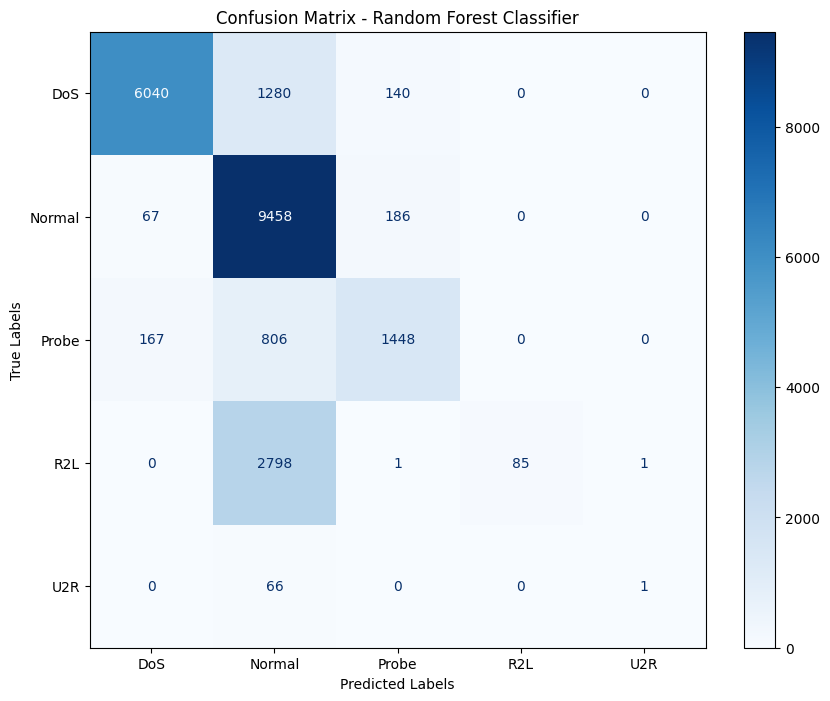

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- STEP 1: TRAIN RANDOM FOREST ON THE WHOLE TRAIN DATA ---
print("Training the final Random Forest model on the full training dataset...")
rf_model.fit(X_train_scaled, y_train)

# --- STEP 2: PREDICT ON THE TEST DATA ---
print("Predicting on the unseen test dataset...")
y_pred = rf_model.predict(X_test_scaled)

# --- STEP 3: GENERATE CLASSIFICATION REPORT ---
# This prints precision, recall, and F1 for Normal, DoS, Probe, R2L, and U2R.
print("\n--- TEST DATASET CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, digits=4))

# --- STEP 4: PLOT THE CONFUSION MATRIX ---
# This creates a visual grid showing correct vs incorrect classifications.
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)

# Plotting the grid with a blue color scale
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

--- TOP 10 FEATURES DRIVING MODEL DECISIONS ---
1. src_bytes: 0.1225
2. flag_SF: 0.0649
3. dst_host_same_srv_rate: 0.0643
4. diff_srv_rate: 0.0501
5. dst_host_serror_rate: 0.0476
6. same_srv_rate: 0.0453
7. flag_S0: 0.0420
8. dst_host_srv_count: 0.0405
9. dst_host_srv_serror_rate: 0.0395
10. dst_bytes: 0.0391




/tmp/ipykernel_1963/1756538345.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:10]], y=feature_names[indices[:10]], palette='mako')


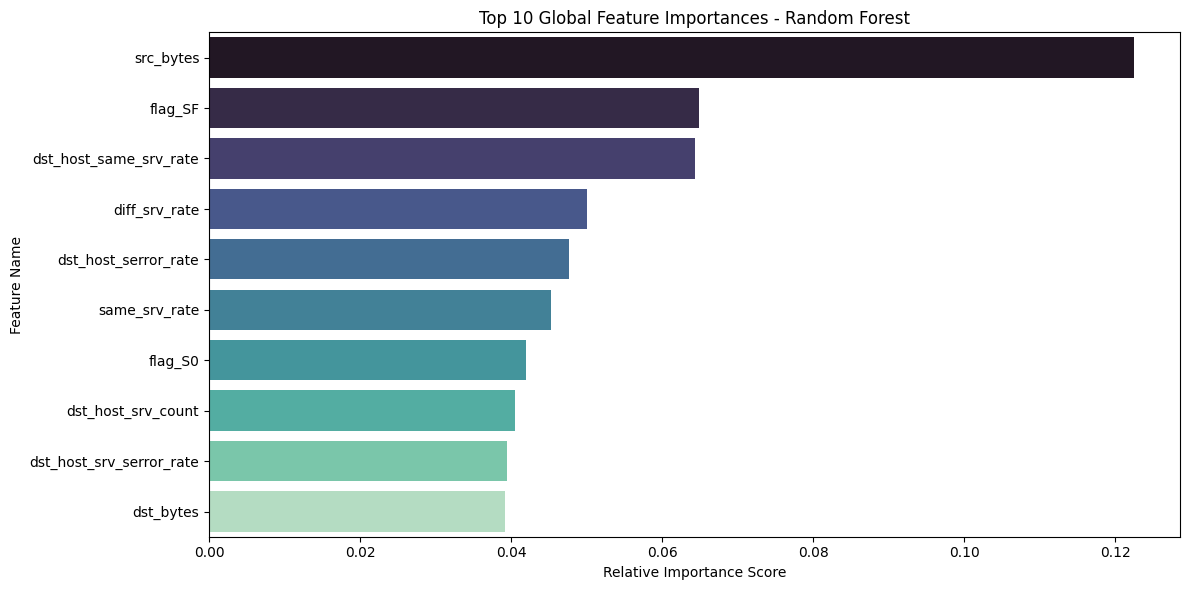

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: EXTRACT FEATURE IMPORTANCES ---
# Get the raw importances from our trained Random Forest
importances = rf_model.feature_importances_

# Get the names of the processed columns
feature_names = X_train_scaled.columns

# Sort features by importance in descending order
indices = np.argsort(importances)[::-1]

# --- STEP 2: PRINT THE TOP 10 FEATURES ---
print("--- TOP 10 FEATURES DRIVING MODEL DECISIONS ---")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
print("\n")

# --- STEP 3: PLOT FEATURE IMPORTANCES ---
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices[:10]], y=feature_names[indices[:10]], palette='mako')
plt.title("Top 10 Global Feature Importances - Random Forest")
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()